# interpretable ML with SHAP




In [1]:
from sklearn.cluster import AgglomerativeClustering

def drop_correlated_features( X , threshold = 0.9 ):
    """
    Args:
        - X (pd.DataFrame) : n,p feature matrix
        - threshold (float) : absolute correlation threshold group variables
    
    Returns:
        - pd.DataFrame : X with only the selected variables
        - dict : keys are the selected features , values are the list of features in the corresponding feature cluster 
    """
    
    corr_threshold = 0.9

    metric = 1 - X.corr().abs()

    HC = AgglomerativeClustering( n_clusters=None , metric='precomputed', linkage = 'single' , distance_threshold = (1-corr_threshold) )
    HC.fit(metric)

    variable_clusters = pd.Series( HC.labels_  , index = X.columns)

    cluster_to_features = variable_clusters.index.groupby(variable_clusters)

    ## keys are the selected feature in the cluster, values are the list of features in the cluster
    selected_features_to_features = { v[0]:list(v) for v in cluster_to_features.values() }

    return X.loc[:,selected_features_to_features.keys()] ,  selected_features_to_features 

In [2]:
import pandas as pd
from sklearn.feature_selection import SelectPercentile
import numpy as np

## loading data
df_xpr = pd.read_csv("../data/TGCA_BRCA_expression_matrix.TPM.csv.gz" , index_col = 0)

df_clinical = pd.read_csv("../data/TGCA_BRCA_clinical_filtered.small.csv",index_col=0)
df_clinical = pd.get_dummies( df_clinical , drop_first=True)

## y is the poor_diagnosis
y = df_clinical.poor_prognosis

## ensuring the expression data is properly ordered
X_xpr = df_xpr.loc[ :, df_clinical.index].transpose() 

## selecting top 1% most variable genes
VT = SelectPercentile( score_func = lambda x,_ : np.var(x , axis = 0) ,
                       percentile = 1
                     )

X = pd.DataFrame( VT.fit_transform(X_xpr), columns=VT.get_feature_names_out() , index = X_xpr.index )
X , features_to_features_cluster = drop_correlated_features( X , threshold = 0.9 )


# adding age and sex to the set of features
X = pd.concat( [ df_clinical[['demographic.days_to_birth','demographic.sex_at_birth_male']] , X ] , axis=1 )



In [3]:
## let's use the reduced set of features which we obtained from lasso in chapter 3
lasso_set = ["demographic.days_to_birth","ENSG00000102144.15","ENSG00000092010.15","ENSG00000178372.8","ENSG00000171209.3","ENSG00000115884.11","ENSG00000109971.14","ENSG00000175356.14","ENSG00000141367.12","ENSG00000101210.13","ENSG00000271503.6","ENSG00000133048.13","ENSG00000182054.10","ENSG00000124107.5","ENSG00000211640.4","ENSG00000143248.13","ENSG00000012660.14","ENSG00000080824.19","ENSG00000175426.11","ENSG00000138326.21","ENSG00000198888.2","ENSG00000205426.10","ENSG00000211648.2","ENSG00000129538.14","ENSG00000158710.15"]
X = X.loc[:,lasso_set]

X.shape

(332, 25)

In [4]:
y = y.values

## SHAP

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_jobs=-1, ccp_alpha = 10**-2.3, n_estimators=250 )
print( f"random forest cross-val accuracy: {cross_val_score(rf,X,y).mean():.3f}" )
_ = rf.fit(X,y)

random forest cross-val accuracy: 0.744


## SHAP basic usage and plots

In [6]:
import shap

%time explainer = shap.Explainer( rf ) ## creates an explainer from our model
%time shap_values = explainer(X) ## compute shap values for the prediction of the models on some data

CPU times: user 37.7 ms, sys: 0 ns, total: 37.7 ms
Wall time: 37.7 ms
CPU times: user 858 ms, sys: 474 µs, total: 859 ms
Wall time: 856 ms


In [7]:
## explainer model is actually a subclass dedicated to trees
explainer

In [8]:
## all shap values for all features and samples
shap_values

.values =
array([[[ 4.55403991e-02, -4.55403991e-02],
        [ 2.68255999e-02, -2.68255999e-02],
        [-3.49535642e-02,  3.49535642e-02],
        ...,
        [ 2.06325143e-03, -2.06325143e-03],
        [-4.56125089e-03,  4.56125089e-03],
        [ 8.65838816e-03, -8.65838816e-03]],

       [[ 1.20441305e-02, -1.20441305e-02],
        [-3.23012555e-02,  3.23012555e-02],
        [ 6.62259443e-02, -6.62259443e-02],
        ...,
        [ 1.08158322e-02, -1.08158322e-02],
        [-2.16987234e-02,  2.16987234e-02],
        [-6.29055657e-03,  6.29055657e-03]],

       [[ 4.77915256e-02, -4.77915256e-02],
        [ 2.73581062e-02, -2.73581062e-02],
        [-3.74233373e-02,  3.74233373e-02],
        ...,
        [ 2.16533199e-03, -2.16533199e-03],
        [ 4.54364554e-03, -4.54364554e-03],
        [ 1.30936954e-03, -1.30936954e-03]],

       ...,

       [[-1.12674534e-01,  1.12674534e-01],
        [-5.46958141e-02,  5.46958141e-02],
        [-5.19911863e-02,  5.19911863e-02],
        

In [9]:
## shap values for a specific feature
shap_values[:,'demographic.days_to_birth']

.values =
array([[ 4.55403991e-02, -4.55403991e-02],
       [ 1.20441305e-02, -1.20441305e-02],
       [ 4.77915256e-02, -4.77915256e-02],
       [ 2.38051520e-02, -2.38051520e-02],
       [ 2.56233096e-02, -2.56233096e-02],
       [-1.33386665e-02,  1.33386665e-02],
       [-6.98901012e-04,  6.98901012e-04],
       [-7.71625498e-02,  7.71625498e-02],
       [ 1.91007433e-02, -1.91007433e-02],
       [-1.63028893e-01,  1.63028893e-01],
       [ 2.05920437e-02, -2.05920437e-02],
       [ 4.50559941e-02, -4.50559941e-02],
       [ 5.42572158e-02, -5.42572158e-02],
       [ 7.10889036e-03, -7.10889036e-03],
       [ 4.91264385e-02, -4.91264385e-02],
       [ 4.80233903e-02, -4.80233903e-02],
       [ 1.99428416e-02, -1.99428416e-02],
       [-4.72433521e-02,  4.72433521e-02],
       [ 5.68834862e-02, -5.68834862e-02],
       [ 3.48921137e-02, -3.48921137e-02],
       [-1.14650694e-01,  1.14650694e-01],
       [-2.40789635e-02,  2.40789635e-02],
       [-7.53071041e-02,  7.53071041e-02],
 

In [10]:
shap_values[:,'demographic.days_to_birth'].values.shape

(332, 2)

There is one column per class 

In [11]:
y[:5]

array([False, False, False, False,  True])

In [12]:
res_df = pd.DataFrame( {'pred':rf.predict( X ) , "truth":y  } )
res_df['prediction_ok'] = res_df.pred == res_df.truth
res_df.prediction_ok.value_counts()

prediction_ok
True     330
False      2
Name: count, dtype: int64

In [13]:
print("5 correct predictions of positive category:")
print( np.flatnonzero( res_df.prediction_ok & res_df.truth )[:5] )
print("5 correct predictions of positive category:")
print( np.flatnonzero( res_df.prediction_ok & ~res_df.truth )[:5] )
print("5 wrong predictions")
print( np.flatnonzero( ~res_df.prediction_ok )[:5] )

5 correct predictions of positive category:
[ 4  5  8  9 20]
5 correct predictions of positive category:
[0 1 2 3 6]
5 wrong predictions
[133 216]


In [14]:
?shap.plots.waterfall

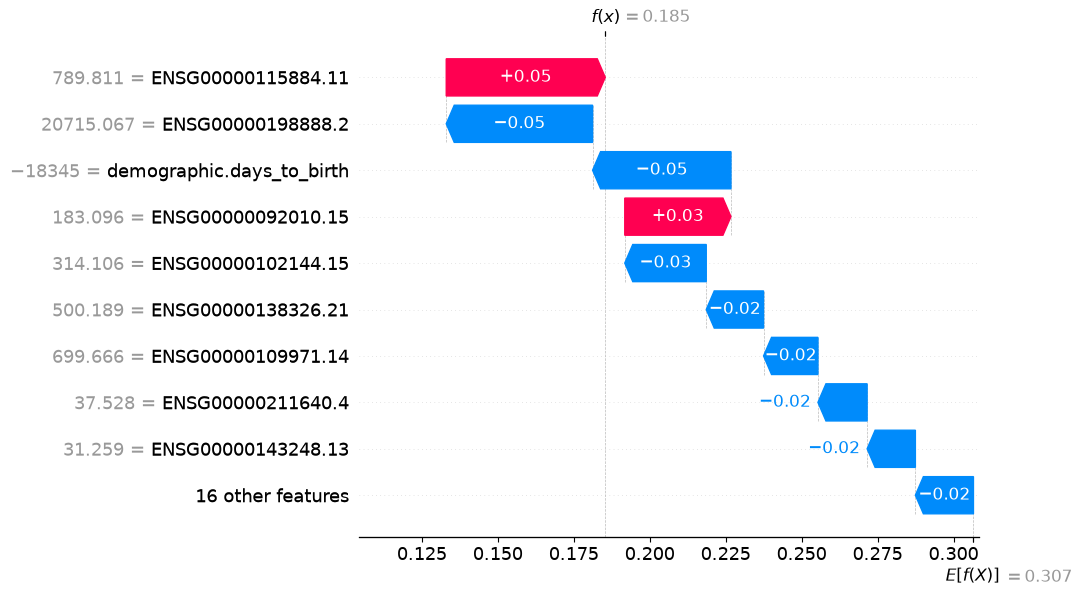

In [15]:
## explaination of a single prediction for category 1
shap.plots.waterfall(shap_values[0,:,1])

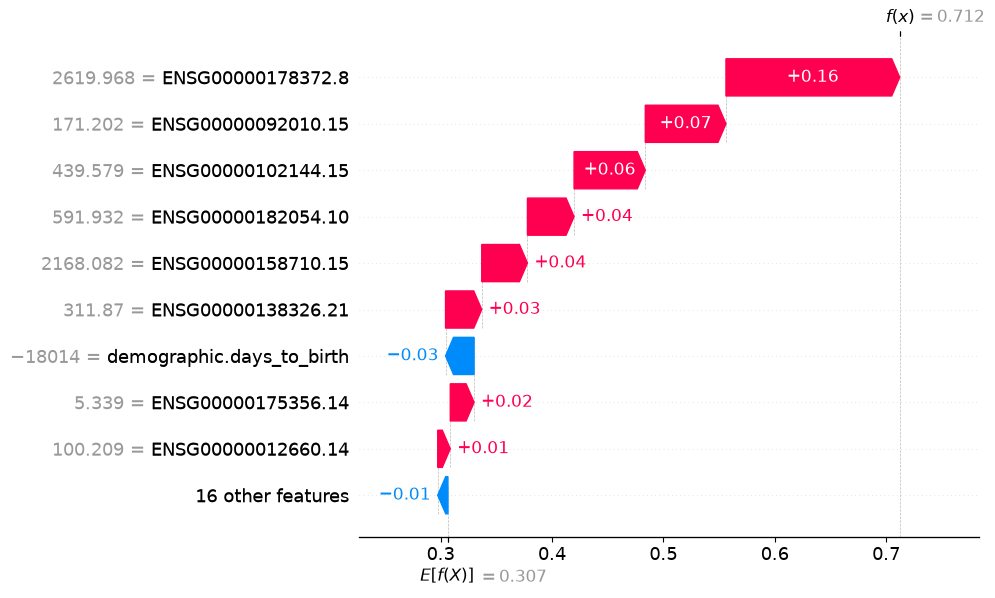

In [16]:
## explaination of a single prediction for category 1
shap.plots.waterfall(shap_values[4,:,1])

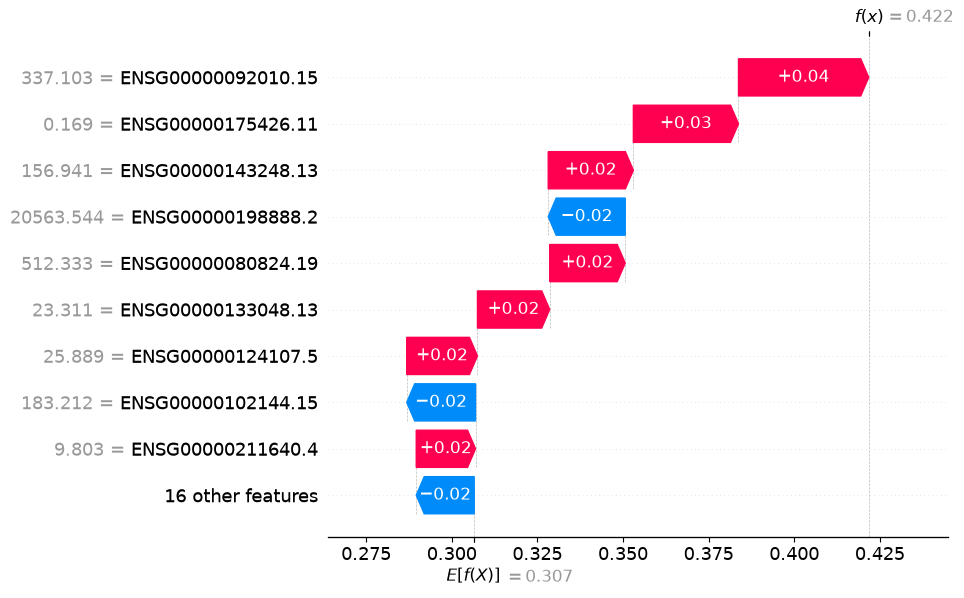

In [17]:
## explaination of a single prediction for category 1
shap.plots.waterfall(shap_values[133,:,1])

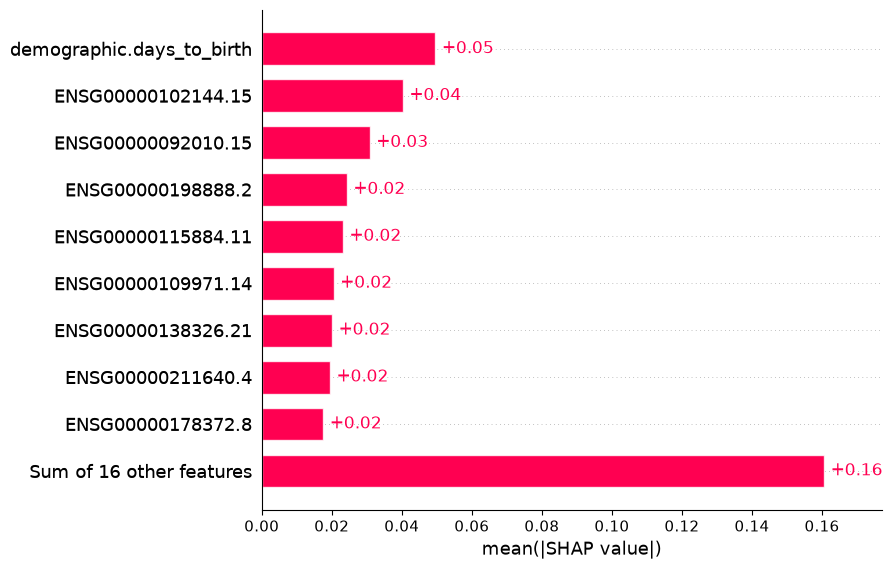

In [18]:
## average SHAP value over all predictions --> proxy of feature importance 
shap.plots.bar(shap_values[...,1])

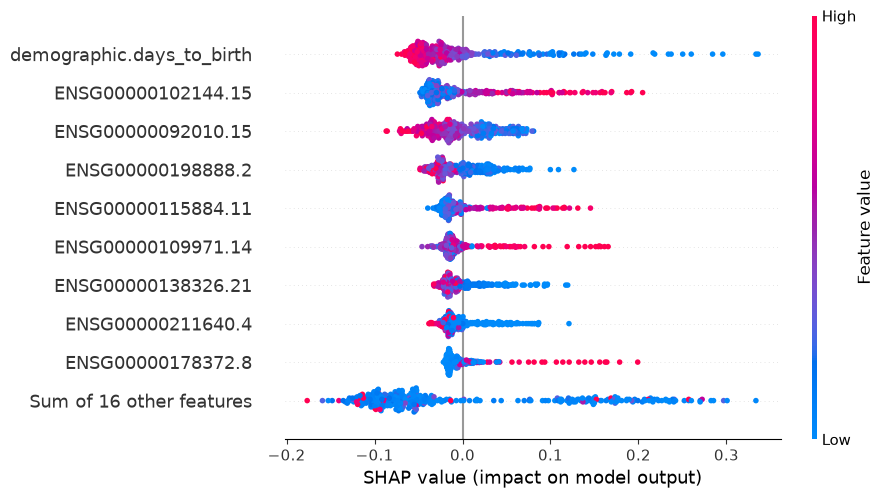

In [19]:
## beeswarm gives us a sense of the relationship between the feature values and the SHAP
shap.plots.beeswarm(shap_values[...,1])

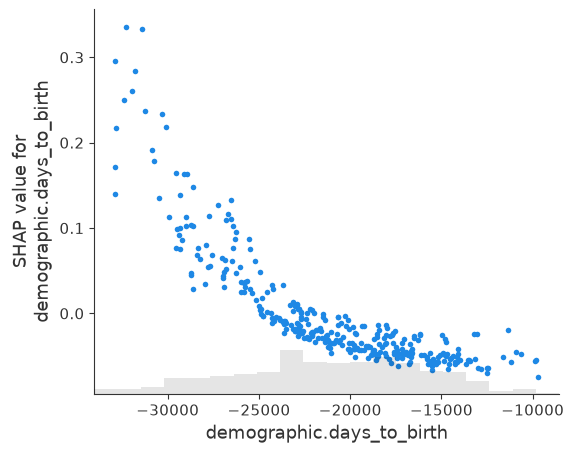

In [20]:
## plotting the SHAP value for each observed age
shap.plots.scatter( shap_values[:,'demographic.days_to_birth',1] )

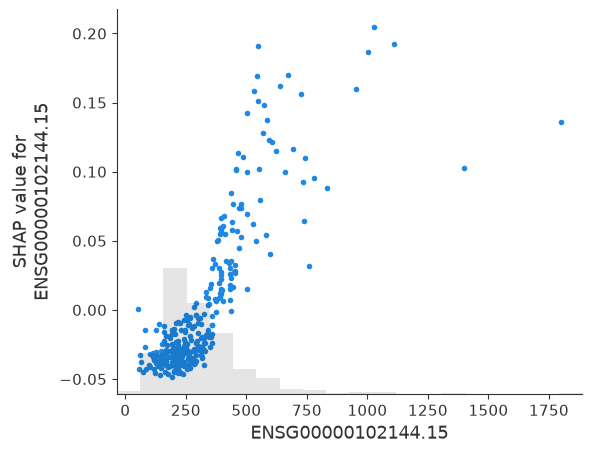

In [21]:
shap.plots.scatter( shap_values[:,'ENSG00000102144.15',1] )

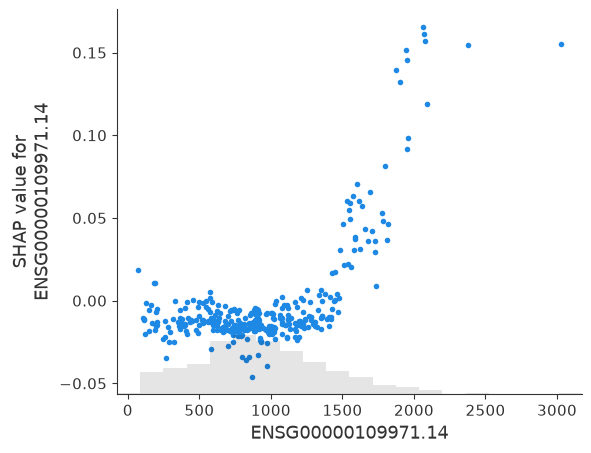

In [22]:
shap.plots.scatter( shap_values[:,'ENSG00000109971.14',1] )

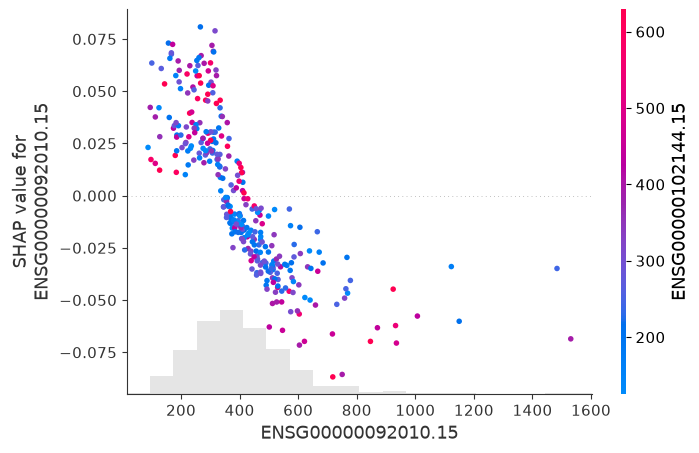

In [35]:
## visualize some of the interaction between feature by coloring according to another variable 
shap.plots.scatter( shap_values[:,'ENSG00000092010.15',1] , color=shap_values[...,1] )

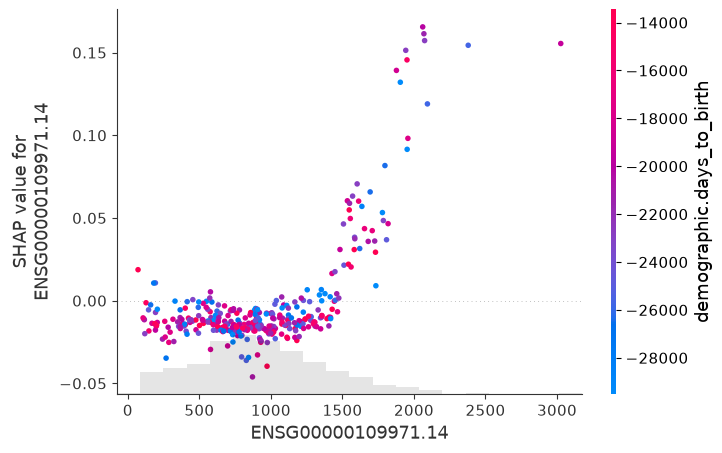

In [24]:
## If you give all shap_values, the library searched for the one which may interact the most
shap.plots.scatter( shap_values[:,'ENSG00000109971.14',1] , color=shap_values[:,'demographic.days_to_birth',1] )

## SHAP interaction values

In [25]:
%%time
shap_interaction_values = explainer.shap_interaction_values(X)

CPU times: user 27.2 s, sys: 123 ms, total: 27.3 s
Wall time: 27.1 s


<Axes: >

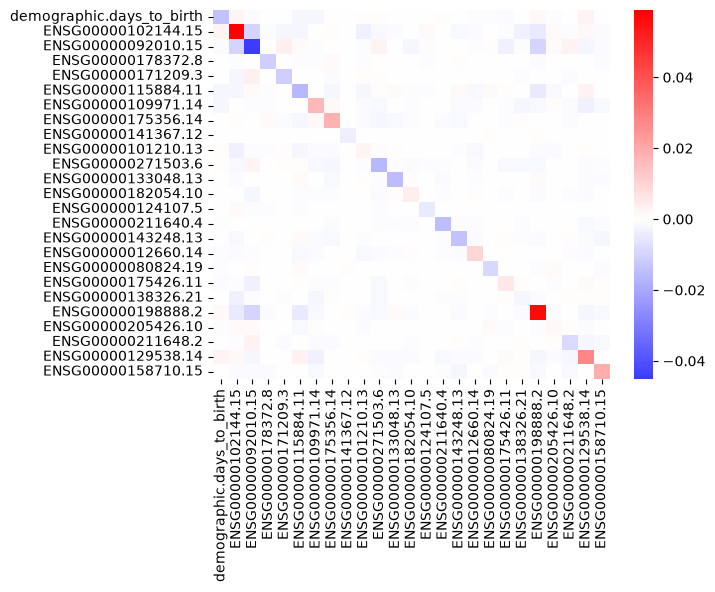

In [26]:
import seaborn as sns
sns.heatmap( shap_interaction_values[1,...,1], 
            xticklabels = X.columns,
            yticklabels = X.columns,
           center = 0, cmap = 'bwr')

The shap interactions for 1 variable (ie. a row of the matrix) sum to the variable shap value

In [27]:
#shap values
shap_values[1,:,1].values

array([-0.01204413,  0.03230126, -0.06622594, -0.01658876, -0.01191826,
       -0.02313434,  0.00157836,  0.00882301, -0.00339585, -0.00807404,
       -0.02714112, -0.01937906, -0.00409429, -0.00659463, -0.02098984,
       -0.02210687, -0.00012058, -0.00882729, -0.00111401, -0.01032637,
        0.026635  ,  0.00079982, -0.01081583,  0.02169872,  0.00629056])

In [28]:
# row sum of shap interactions
shap_interaction_values[1,...,1].sum(axis = 1)

array([-0.01204413,  0.03230126, -0.06622594, -0.01658876, -0.01191826,
       -0.02313434,  0.00157836,  0.00882301, -0.00339585, -0.00807404,
       -0.02714112, -0.01937906, -0.00409429, -0.00659463, -0.02098984,
       -0.02210687, -0.00012058, -0.00882729, -0.00111401, -0.01032637,
        0.026635  ,  0.00079982, -0.01081583,  0.02169872,  0.00629056])

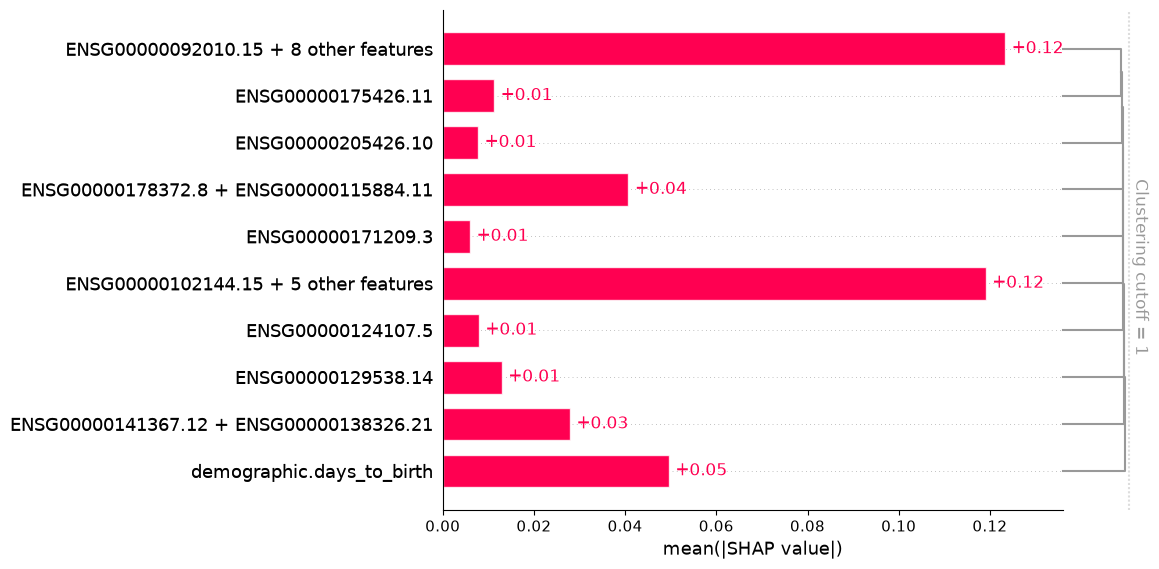

In [36]:
clustering = shap.utils.hclust(X, y)
shap.plots.bar(shap_values[...,1], clustering=clustering,clustering_cutoff=1.0)

### exercise

We train a Logistic regression instead.

Look at the corresponding SHAP values. What do you see?


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


Xs = pd.DataFrame( StandardScaler().fit_transform(X),
                  columns = X.columns )
LR = LogisticRegression(C=np.inf)


print( f"logistic regression cross-val accuracy: {cross_val_score( LR, Xs,y).mean():.3f}" )
_ = LR.fit(Xs,y)

logistic regression cross-val accuracy: 0.795


/home/wandrille/micromamba/envs/py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/wandrille/micromamba/envs/py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/wandrille/micromamba/envs/py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/wandrille/micromamba/envs/py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/wandrille/micromamba/envs/py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


In [31]:
explainer2 = shap.Explainer( LR , Xs ) ## creates an explainer from our model
shap_values2 = explainer2( Xs ) ## compute shap values for the prediction of the models on some data

Background dataset has 332 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=332 when initializing the masker.


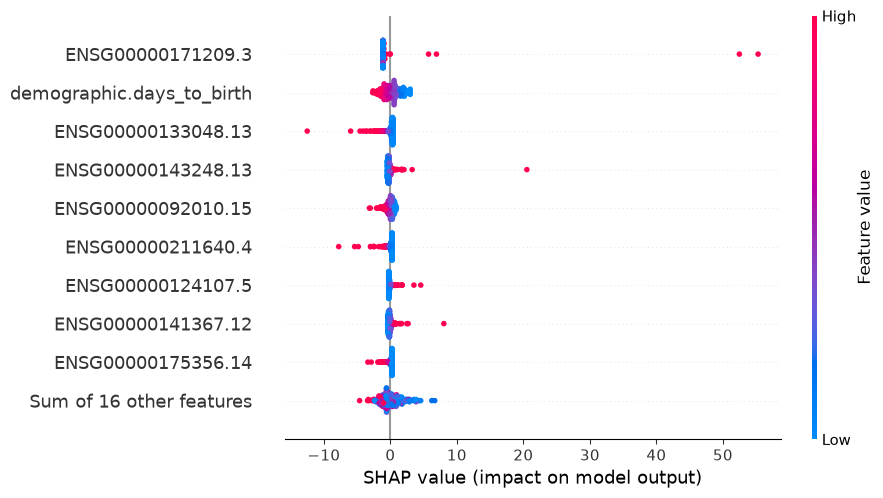

In [32]:
shap.plots.beeswarm(shap_values2)

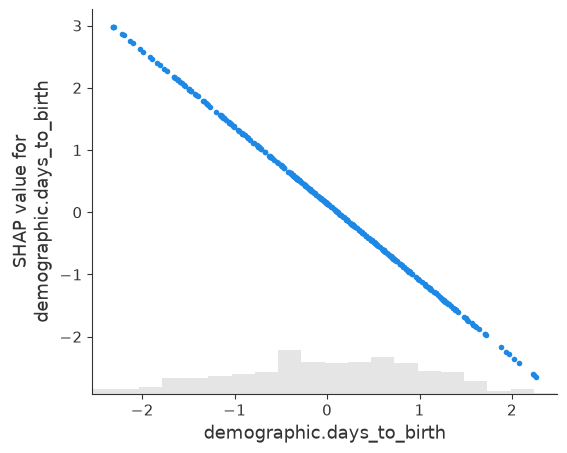

In [33]:
shap.plots.scatter( shap_values2[: , "demographic.days_to_birth"] )

### different explainer types

In [37]:
%%time
explainer = shap.Explainer( rf ) ## defaults to TreeExplainer
print(type(explainer))
# TreeExplainer: 
#  * explores the tree ensemble to compute the SHAP values efficiently
#  * somewhat built-in the trees libraries nowadays -> extra fast computation
shap_values = explainer(X) 


<class 'shap.explainers._tree.TreeExplainer'>
CPU times: user 947 ms, sys: 3.97 ms, total: 951 ms
Wall time: 946 ms


In [38]:
%%time

explainer = shap.Explainer( LR , Xs ) 
shap_values = explainer(Xs) 

explainer

Background dataset has 332 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=332 when initializing the masker.


CPU times: user 18.5 ms, sys: 990 µs, total: 19.5 ms
Wall time: 18.4 ms


In [39]:
%%time
explainer = shap.Explainer( LR.predict_proba , Xs ) 
shap_values = explainer(Xs) 

explainer

Background dataset has 332 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=332 when initializing the masker.
PermutationExplainer explainer: 333it [00:15, 13.15it/s]                                  

CPU times: user 14.7 s, sys: 478 ms, total: 15.2 s
Wall time: 15.4 s


[permutation explainer](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/explainers/Permutation.html)
 * uses smart permutation scheme to estimate SHAP values
 * needs a "background" sample which is used to "simulate" values for the masked features

An alternative is to explicitely say that it is a Linear model:

In [40]:
%%time
# explain the model's predictions using SHAP
explainer = shap.explainers.Linear(LR, Xs)
shap_values = explainer(Xs)

Background dataset has 332 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=332 when initializing the masker.


CPU times: user 44.7 ms, sys: 3.97 ms, total: 48.6 ms
Wall time: 46.7 ms


In [41]:
explainer

But in some case you won't have a choice and you need to go for a "generic" explainer such as PermutationExplainer

For example, for a KNN:

In [42]:
%%time 
from sklearn.neighbors import KNeighborsClassifier

KNN = KNeighborsClassifier(n_neighbors=10)
KNN.fit(Xs, y)


explainer = shap.Explainer( KNN.predict_proba , Xs) 
shap_values = explainer(Xs) 

Background dataset has 332 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=332 when initializing the masker.
PermutationExplainer explainer: 333it [00:37,  6.68it/s]                                  

CPU times: user 2min 27s, sys: 145 ms, total: 2min 27s
Wall time: 37.8 s


See the API documentation for [other "explainers"](https://shap.readthedocs.io/en/latest/api.html#explainers), either generic or adapted to specific kind of models.


### causation, correlation, and interpretation of predictive models

We are sure you have heard it a large number of time, but this message really is really worth repeating.

The SHAP documentation actually proposes an [insightful article](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/Be%20careful%20when%20interpreting%20predictive%20models%20in%20search%20of%20causal%20insights.html) on the topic of misleading interpretation.

Our advise is to read it attentively, meditate on the subject, and then read it again.

